# Pricing Analysis and Optimization in E-Commerce Products with Machine Learning

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
)
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

results = pd.read_csv('ecommerce_data.csv', parse_dates=['order_created_at'])
product_names_categories = results[['product_name', 'product_category', 'product_id']].drop_duplicates()

In [2]:
pd.set_option('display.max_colwidth', None)
products = results[['product_id', 'product_name']].drop_duplicates()

temp = results.drop(columns=['product_category', 'product_id']).drop_duplicates()

product_stats = temp.groupby(
    ['product_name'], as_index=False).agg(
        avg_cost=('product_cost', 'mean'),
        avg_sale_price=('sale_price', 'mean'),
        units_sold=('sale_price', 'count')
    )

product_stats['total_revenue'] = product_stats["avg_sale_price"] * product_stats["units_sold"]
product_stats["profit"] = (
    product_stats["avg_sale_price"] - product_stats["avg_cost"]
) * product_stats["units_sold"]

product_stats = product_stats[['product_name', 'avg_cost', 'avg_sale_price', 'units_sold', 'total_revenue', 'profit']]
product_stats.round(2).sort_values(by='profit', ascending=False).head(7)

,product_name,avg_cost,avg_sale_price,units_sold,total_revenue,profit
23686,The North Face Apex Bionic Soft Shell Jacket - Men's,425.88,903.0,27,24381.0,12882.20
20313,Quiksilver Men's Rockefeller Walkshort,472.27,903.0,16,14448.0,6891.70
17530,NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outstanding Support and Comfort*,445.48,903.0,15,13545.0,6862.80
5454,Canada Goose Women's Mystique,329.00,750.0,15,11250.0,6315.00
23690,The North Face Denali Down Womens Jacket 2013,417.88,903.0,13,11739.0,6306.55
7523,Darla,404.60,999.0,10,9990.0,5944.05
16625,Mens Nike AirJordan Varsity Hoodie Jacket Grey / Black 451582-066,409.06,903.0,12,10836.0,5927.29


In [3]:
top_selling_products = product_stats.sort_values(
    by=['units_sold', 'total_revenue'],
    ascending=False
).head(7)

top_selling_products

,product_name,avg_cost,avg_sale_price,units_sold,total_revenue,profit
26560,Wrangler Men's Premium Performance Cowboy Cut Jean,26.436060,48.068573,49,2355.360054,1059.993106
19331,Pearl iZUMi Attack Sock 3-Pack,11.347005,23.230000,41,952.429981,487.202779
17122,Motherhood Maternity: 3 Pack Maternity Bikini Panties,6.278156,14.980000,39,584.219982,339.371889
24551,True Religion Men's Ricky Straight Jean,129.375630,244.623686,38,9295.700073,4379.426137
15550,Lucky Brand Mens Men's 361 Vintage Straight Denim Jean,52.146243,99.000000,37,3663.000000,1733.589002
10106,Fruit of the Loom Women's 6-Pack Crew Socks,4.858919,10.756757,37,398.000000,218.220001
23774,Thorlo Unisex Experia Running Sock,7.476924,15.990000,35,559.649992,297.957655


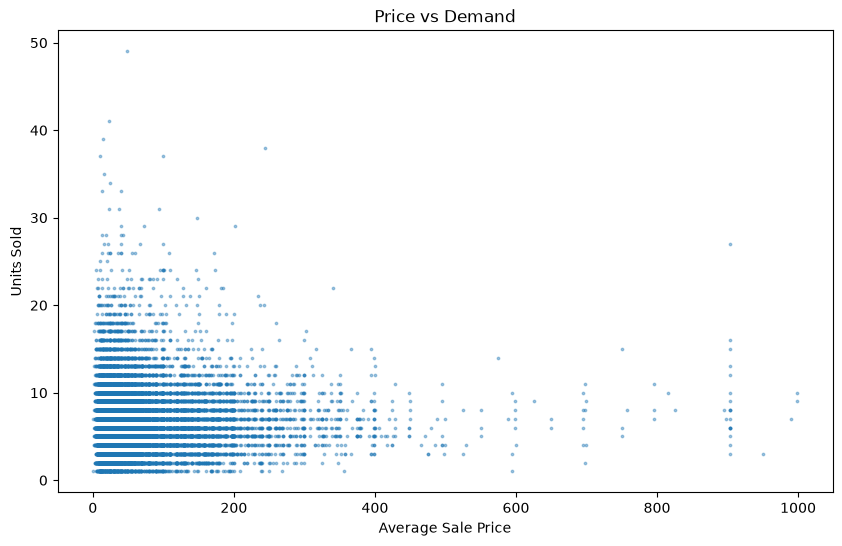

In [4]:

plt.figure(figsize=(10,6))
plt.scatter(
    product_stats['avg_sale_price'],
    product_stats['units_sold'],
    alpha=0.4,
    s=3
)
plt.xlabel('Average Sale Price')
plt.ylabel('Units Sold')
plt.title('Price vs Demand')
plt.show()

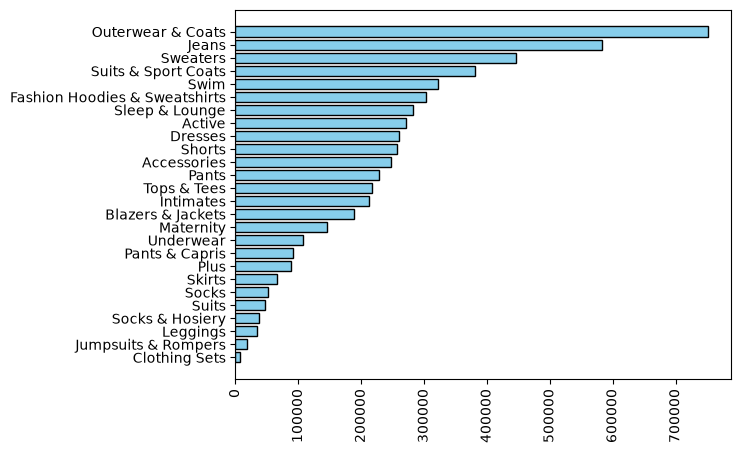

In [5]:
category_revenues = results.groupby('product_category', as_index=False).agg(
    category_total_revenue=('sale_price', 'sum'),
    category_total_cost=('product_cost', 'sum')
  )
category_revenues['category_profit'] = category_revenues['category_total_revenue'] - category_revenues['category_total_cost']
category_revenues = category_revenues.sort_values(by='category_profit', ascending=True)

fig, ax = plt.subplots()
plt.barh(
    category_revenues['product_category'],
    category_revenues['category_profit'],
    color='skyblue', edgecolor='black'
  )
plt.xticks(rotation='vertical')
plt.show()

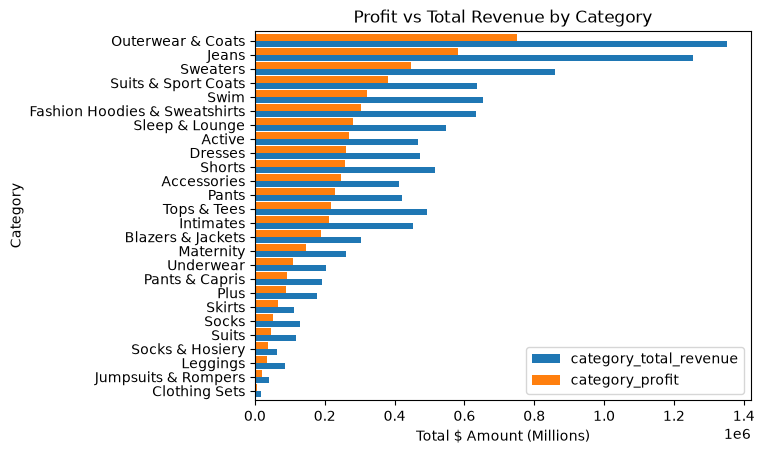

In [6]:
category_revenues.set_index(
    'product_category')[['category_total_revenue', 'category_profit']].plot(
    kind='barh', width=0.9)

plt.xlabel('Total $ Amount (Millions)')
plt.ylabel('Category')
plt.title('Profit vs Total Revenue by Category')

plt.show()


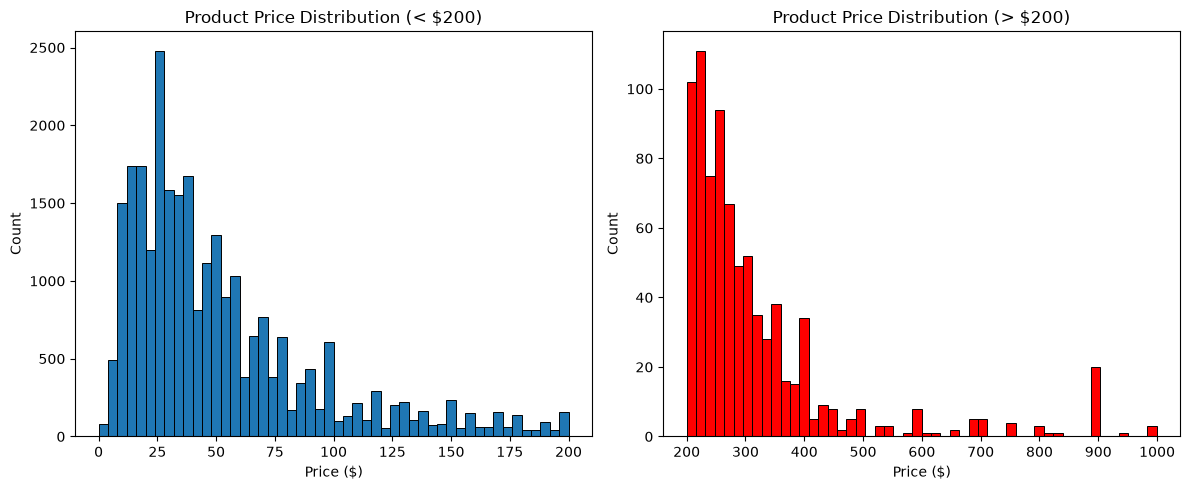

In [7]:
product_prices = results[['product_name', 'product_retail_price']].drop_duplicates()
product_prices_low = product_prices[product_prices['product_retail_price'] < 200]
product_prices_high = product_prices[product_prices['product_retail_price'] >= 200] #rm outliers

# 1. Create a figure with 1 row and 2 columns of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot the first chart (Revenue vs Profit)
ax1.hist(product_prices_low['product_retail_price'],
         bins=50, edgecolor='black', linewidth=0.7)
ax1.set_title("Product Price Distribution (< $200)")
ax1.set_xlabel("Price ($)")
ax1.set_ylabel("Count")

# 3. Plot a second chart on the second axis (e.g., a simple line plot)
ax2.hist(product_prices_high['product_retail_price'],
         bins=50, color='red', edgecolor='black', linewidth=0.7)
ax2.set_title("Product Price Distribution (> $200)")
ax2.set_xlabel("Price ($)")
ax2.set_ylabel("Count")

# 4. Prevent overlapping labels and display
plt.tight_layout()
plt.show()

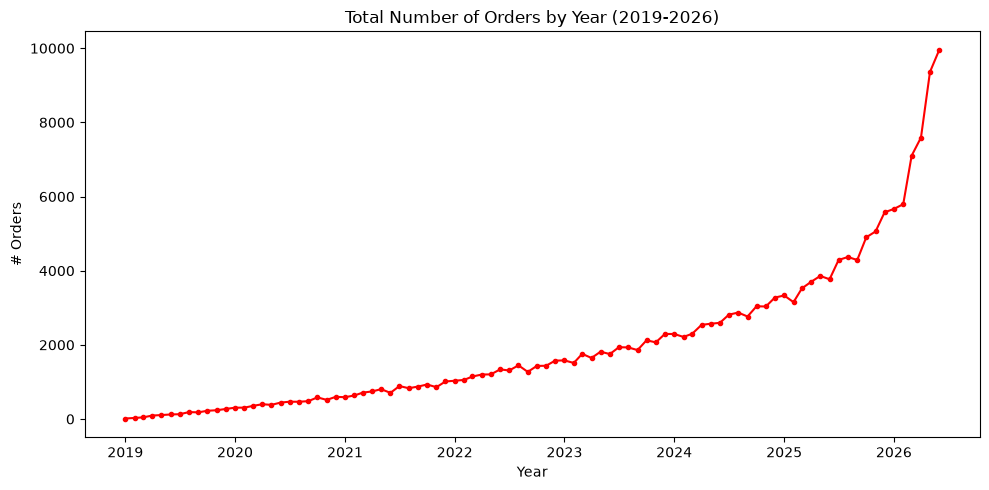

In [8]:
results_mod = results.copy()
results_mod['order_created_at'] = pd.to_datetime(
    results_mod['order_created_at'], format='mixed', utc=True
)
results_mod['order_created_at'] = results_mod['order_created_at'].dt.to_period('M')
results_mod['order_created_at'] = results_mod['order_created_at'].dt.to_timestamp()
results_mod = results_mod.rename(
    columns={'order_created_at': 'month'}
)
monthly_total_orders = results_mod.groupby(
    ['month'], as_index=False).agg(
        num_orders=('product_id', 'count')
    )

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_total_orders['month'], monthly_total_orders['num_orders'],
        marker='o', color='red', markersize=3)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Total Number of Orders by Year (2019-2026)")
plt.xlabel("Year")
plt.ylabel("# Orders")
plt.tight_layout()
plt.show()

In [9]:
monthly_products = results_mod.groupby(
    ['product_name', 'product_category', 'month', 'sale_price'], as_index=False
  ).agg(
      monthly_units_sold=('product_id', 'count')
  )

monthly_products.sort_values(by='monthly_units_sold', ascending=False)

,product_name,product_category,month,sale_price,monthly_units_sold
69913,Hanes Men's 4 Pack Boxer Brief,Underwear,2026-05-01,25.000000,6
7129,Alki'i A-Lined Mid Length Skirt with Elastic Waistband,Skirts,2026-05-01,15.990000,5
135594,Seafolly Women's Goddess D Underwire Pleat Maillot,Swim,2026-06-01,161.000000,5
105573,Motherhood Maternity: 3 Pack Maternity Bikini Panties,Maternity,2026-06-01,14.980000,5
165364,Wrangler Men's Ranger Pant,Pants,2026-05-01,49.880001,5
...,...,...,...,...,...
58428,Fishworks Quatro Boardshorts,Swim,2020-12-01,69.989998,1
58429,Fishworks Quatro Boardshorts,Swim,2025-02-01,69.989998,1
58431,Fit 4 U Women's Diva Texture 3 Tiered V-Neck Tankini,Swim,2023-07-01,104.000000,1
58432,Fit 4 U Women's Diva Texture 3 Tiered V-Neck Tankini,Swim,2023-10-01,104.000000,1


# Machine Learning Analysis

This section extends the exploratory analysis with unsupervised and supervised learning models to segment products and predict demand. 

In [10]:
# create SKU-level table
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

# One row per SKU (product_id)
sku_features = results.groupby('product_id', as_index=False).agg(
    product_name=('product_name', 'first'),
    product_category=('product_category', 'first'),
    product_department=('product_department', 'first'),
    product_brand=('product_brand', 'first'),
    sale_price=('sale_price', 'first'),
    product_cost=('product_cost', 'first'),
    units_sold=('sale_price', 'count'),
    total_revenue=('sale_price', 'sum'),
)

sku_features['profit_per_unit'] = sku_features['sale_price'] - sku_features['product_cost']
sku_features['total_profit'] = sku_features['profit_per_unit'] * sku_features['units_sold']
sku_features['margin_pct'] = sku_features['profit_per_unit'] / sku_features['sale_price']

print(f"SKU-level table: {sku_features.shape[0]:,} products")
sku_features.describe().round(2)

SKU-level table: 29,049 products


,product_id,sale_price,product_cost,units_sold,total_revenue,profit_per_unit,total_profit,margin_pct
count,29049.00,29049.00,29049.00,29049.00,29049.00,29049.00,29049.00,29049.00
mean,14571.54,59.23,28.49,6.26,374.60,30.74,194.40,0.51
std,8407.14,65.92,30.64,2.55,491.85,36.27,268.10,0.07
min,1.00,0.02,0.01,1.00,0.02,0.01,0.01,0.33
25%,7288.00,24.00,11.28,4.00,120.00,11.61,60.73,0.45
50%,14580.00,39.99,19.68,6.00,237.00,20.06,117.35,0.51
75%,21854.00,69.95,34.44,8.00,444.00,35.84,224.02,0.57
max,29120.00,999.00,557.15,18.00,14448.00,594.40,7155.37,0.67


# Part I: Unsupervised Learning

## 1.1 K-Means Product Segmentation




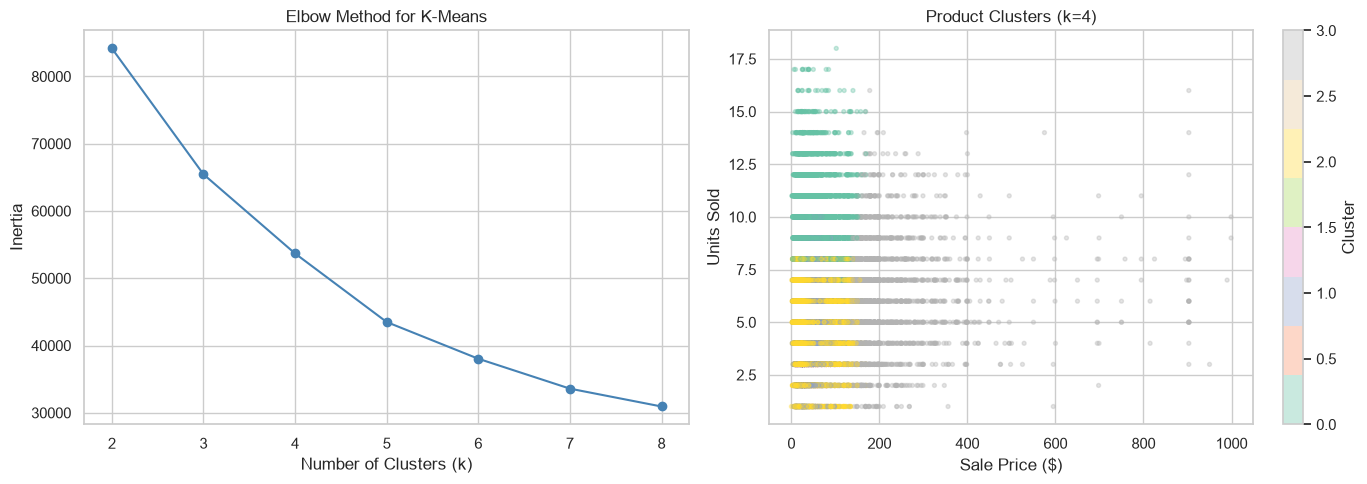

In [11]:
cluster_cols = ['sale_price', 'product_cost', 'margin_pct', 'units_sold']
X_cluster = sku_features[cluster_cols].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Elbow method to choose k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for K-Means')

# Fit final model with k=4
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
sku_features['cluster'] = kmeans.fit_predict(X_cluster_scaled)

scatter = axes[1].scatter(
    sku_features['sale_price'],
    sku_features['units_sold'],
    c=sku_features['cluster'],
    cmap='Set2',
    alpha=0.35,
    s=8
)
axes[1].set_xlabel('Sale Price ($)')
axes[1].set_ylabel('Units Sold')
axes[1].set_title(f'Product Clusters (k={N_CLUSTERS})')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.show()

,n_products,avg_price,avg_cost,avg_margin,avg_units_sold,avg_total_profit
cluster,,,,,,
0,7204,47.21,22.70,0.52,9.37,229.27
1,9447,40.88,22.84,0.44,5.29,94.52
2,9950,46.11,19.79,0.57,4.93,129.79
3,2448,218.70,102.66,0.52,6.27,739.90



Top 3 categories per cluster:


,cluster,product_category,count
15,0,Shorts,605
22,0,Sweaters,595
5,0,Fashion Hoodies & Sweatshirts,525
29,1,Intimates,1587
43,1,Tops & Tees,1410
30,1,Jeans,904
45,2,Accessories,1101
46,2,Active,983
64,2,Swim,650
73,3,Jeans,555


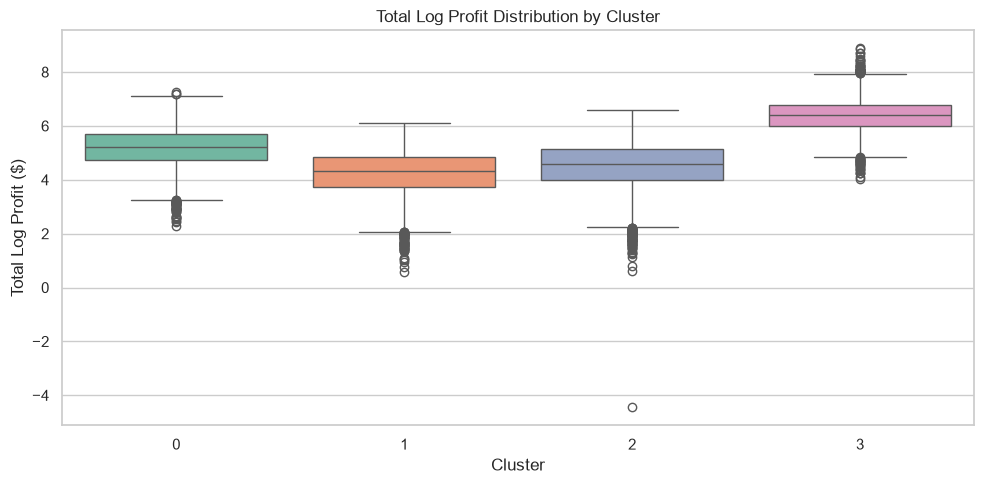

In [12]:
# Cluster profiles — average characteristics per segment
cluster_profile = (
    sku_features.groupby('cluster')[cluster_cols + ['total_profit']]
    .mean()
    .round(2)
    .rename(columns={
        'sale_price': 'avg_price',
        'product_cost': 'avg_cost',
        'margin_pct': 'avg_margin',
        'units_sold': 'avg_units_sold',
        'total_profit': 'avg_total_profit'
    })
)
cluster_profile['n_products'] = sku_features.groupby('cluster').size()
cluster_profile = cluster_profile[['n_products'] + [c for c in cluster_profile.columns if c != 'n_products']]

# Top categories in each cluster
top_cats = (
    sku_features.groupby(['cluster', 'product_category'])
    .size()
    .reset_index(name='count')
    .sort_values(['cluster', 'count'], ascending=[True, False])
    .groupby('cluster')
    .head(3)
)

display(cluster_profile)
print('\nTop 3 categories per cluster:')
display(top_cats)

sku_features['log_total_profit'] = np.log(sku_features['total_profit'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sku_features, x='cluster', y='log_total_profit', hue='cluster', palette='Set2', ax=ax, legend=False)
ax.set_title('Total Log Profit Distribution by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Total Log Profit ($)')
plt.tight_layout()
plt.show()

## 1.2 PCA Visualization (Product Pricing Level)

PCA projects the standardized K-Means feature space into 2 principal components, revealing how product clusters separate in a lower-dimensional view.

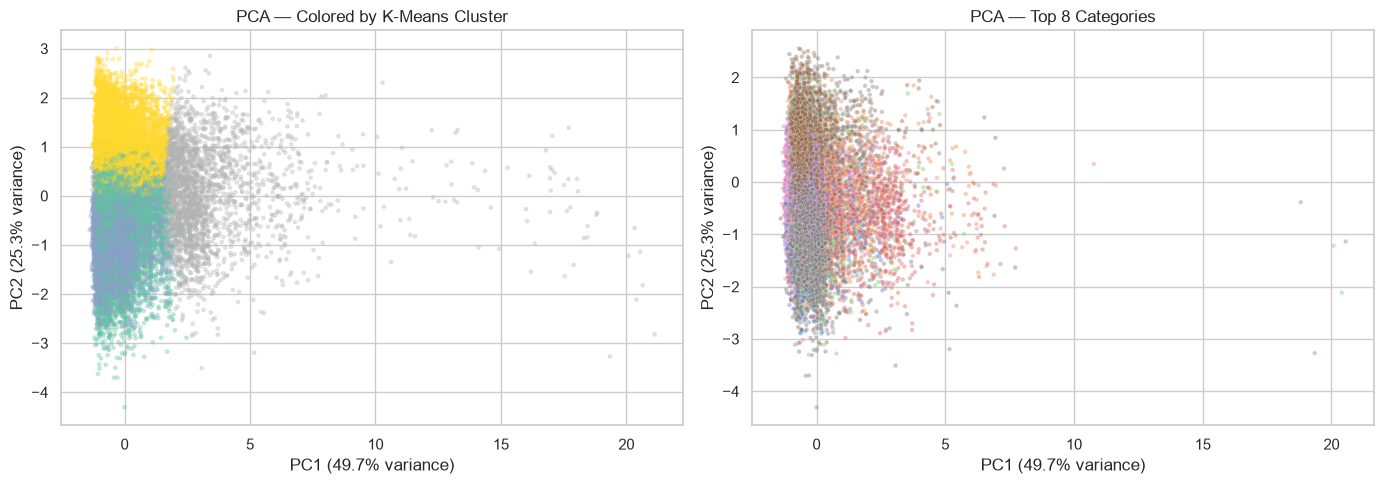

Explained variance ratio: [0.497 0.253]
Total variance captured: 0.75


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
sku_features['pca_1'] = X_pca[:, 0]
sku_features['pca_2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colored by cluster
axes[0].scatter(
    sku_features['pca_1'], sku_features['pca_2'],
    c=sku_features['cluster'], cmap='Set2', alpha=0.3, s=6
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA — Colored by K-Means Cluster')

# Colored by category (top 8 categories for readability)
top_categories = sku_features['product_category'].value_counts().head(8).index
sku_top = sku_features[sku_features['product_category'].isin(top_categories)]

sns.scatterplot(
    data=sku_top, x='pca_1', y='pca_2',
    hue='product_category', alpha=0.4, s=10, ax=axes[1], legend=False
)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA — Top 8 Categories')
plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
print('Total variance captured:', pca.explained_variance_ratio_.sum().round(3))


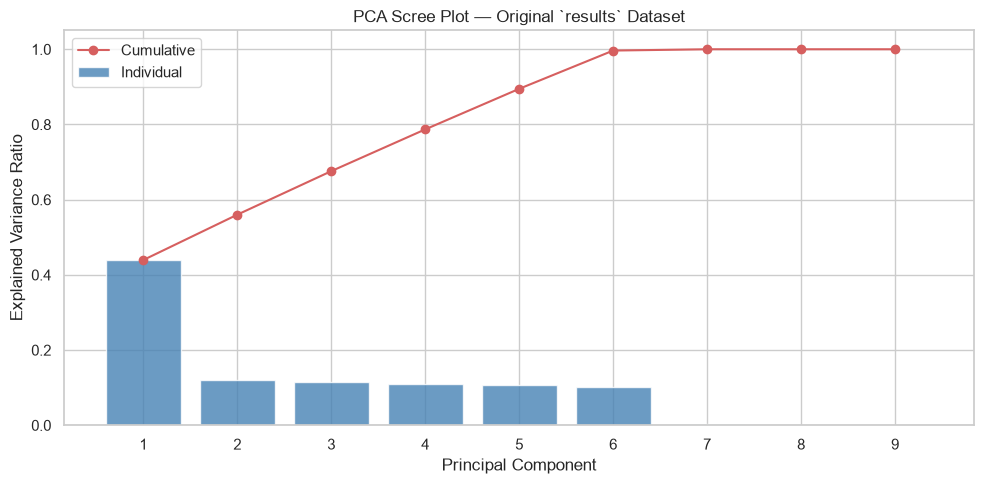

PC1: 44.0%  (cumulative: 44.0%)
PC2: 12.1%  (cumulative: 56.0%)
PC3: 11.6%  (cumulative: 67.6%)
PC4: 11.1%  (cumulative: 78.7%)
PC5: 10.8%  (cumulative: 89.5%)
PC6: 10.2%  (cumulative: 99.7%)
PC7: 0.3%  (cumulative: 100.0%)
PC8: 0.0%  (cumulative: 100.0%)
PC9: 0.0%  (cumulative: 100.0%)


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build numeric feature matrix from the original order-line data
pca_results = results.copy()
pca_results['profit'] = pca_results['sale_price'] - pca_results['product_cost']
pca_results['margin_pct'] = pca_results['profit'] / pca_results['sale_price']

pca_feature_cols = [
    'sale_price', 'product_cost', 'product_retail_price',
    'profit', 'margin_pct', 'user_age',
    'user_latitude', 'user_longitude', 'distribution_center_id'
]

X_results = pca_results[pca_feature_cols].dropna()
meta = pca_results.loc[X_results.index, [
    'product_category', 'product_department', 'user_gender', 'sale_price'
]]

results_scaler = StandardScaler()
X_results_scaled = results_scaler.fit_transform(X_results)

# Fit PCA on all order lines
pca_full = PCA()
pca_full.fit(X_results_scaled)

# Scree plot — how many components to keep?
fig, ax = plt.subplots(figsize=(10, 5))
n_show = len(pca_feature_cols)
x_pos = np.arange(1, n_show + 1)
ax.bar(x_pos, pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8, label='Individual')
ax.plot(x_pos, pca_full.explained_variance_ratio_.cumsum(), 'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot — Original `results` Dataset')
ax.set_xticks(x_pos)
ax.legend()
plt.tight_layout()
plt.show()

for i, var in enumerate(pca_full.explained_variance_ratio_, start=1):
    print(f'PC{i}: {var:.1%}  (cumulative: {pca_full.explained_variance_ratio_[:i].sum():.1%})')

Feature loadings (absolute value = strength of influence):


,PC1,PC2
sale_price,0.503,-0.002
product_cost,0.493,-0.013
product_retail_price,0.503,-0.002
profit,0.498,0.007
margin_pct,0.067,0.078
user_age,-0.000,0.067
user_latitude,-0.002,0.703
user_longitude,0.001,0.702
distribution_center_id,-0.008,-0.058


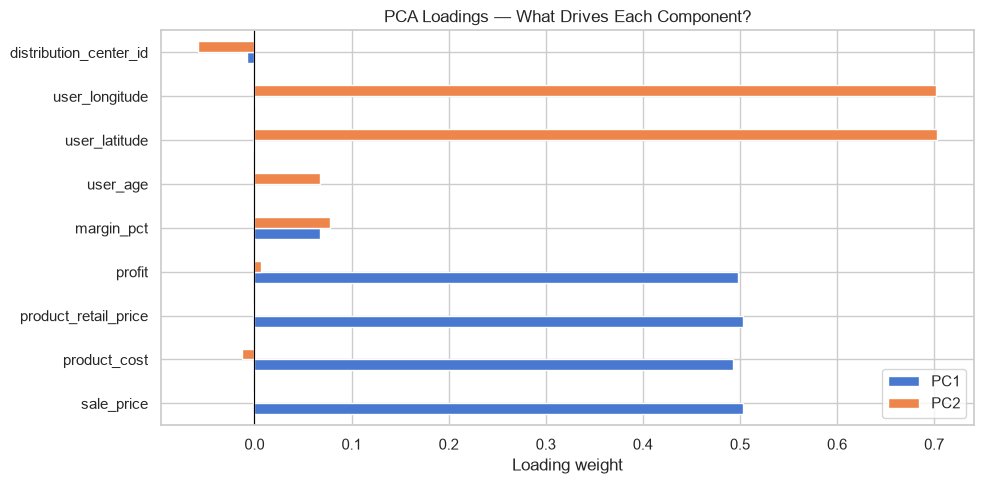

In [15]:
# 2-component PCA for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_results = pca_2d.fit_transform(X_results_scaled)

pca_results_df = meta.copy()
pca_results_df['PC1'] = X_pca_results[:, 0]
pca_results_df['PC2'] = X_pca_results[:, 1]

# Loadings — which original features drive each component?
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=pca_feature_cols,
    columns=['PC1', 'PC2']
).round(3)

print('Feature loadings (absolute value = strength of influence):')
display(loadings)

fig, ax = plt.subplots(figsize=(10, 5))
loadings.plot(kind='barh', ax=ax)
ax.set_title('PCA Loadings — What Drives Each Component?')
ax.set_xlabel('Loading weight')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


# Part II: Supervised Learning 

## 2.1 Predict Monthly Category Demand with Gradient Boosting Trees

In [16]:
# Make a copy so the original results dataframe is not modified
results_gbm = results.copy()

# Convert each order date to the first day of its month
results_gbm["month"] = (
    pd.to_datetime(
        results_gbm["order_created_at"],
        format="mixed",
        utc=True
    )
    .dt.tz_localize(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Count the number of orders for each category in each month
monthly_cat = (
    results_gbm
    .groupby(["product_category", "month"])
    .size()
    .reset_index(name="orders")
    .sort_values(["product_category", "month"])
    .reset_index(drop=True)
)

# Create lag features separately for each product category

lag_frames = []

for category, category_data in monthly_cat.groupby("product_category"):
    category_data = category_data.sort_values("month").copy()

    # Orders in the immediately preceding month
    category_data["lag1"] = category_data["orders"].shift(1)

    # Orders from two months earlier
    category_data["lag2"] = category_data["orders"].shift(2)

    # Average orders over the previous three months
    # shift(1) prevents the current month's demand from leaking
    # into its own prediction
    category_data["roll3"] = (
        category_data["orders"]
        .shift(1)
        .rolling(window=3, min_periods=1)
        .mean()
    )

    lag_frames.append(category_data)

# Combine all categories and remove rows without enough lag history
monthly_demand = (
    pd.concat(lag_frames, ignore_index=True)
    .dropna(subset=["lag1", "lag2", "roll3"])
    .sort_values(["month", "product_category"])
    .reset_index(drop=True)
)

feature_cols_demand = ["lag1", "lag2", "roll3"]

# Time-based train/test split
# Train on earlier months and test on later months
split_month = monthly_demand["month"].quantile(0.80)

train_demand = monthly_demand[
    monthly_demand["month"] <= split_month
].copy()

test_demand = monthly_demand[
    monthly_demand["month"] > split_month
].copy()

X_train_d = train_demand[feature_cols_demand]
X_test_d = test_demand[feature_cols_demand]

y_train_d = train_demand["orders"]
y_test_d = test_demand["orders"]

print(f"Split month: {split_month:%Y-%m}")
print(f"Training rows: {len(train_demand):,}")
print(f"Testing rows: {len(test_demand):,}")

gbm_demand = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=100,
            max_depth=4,
            random_state=42
        )
    )
])

gbm_demand.fit(X_train_d, y_train_d)

# Generate test-set predictions
pred_demand = gbm_demand.predict(X_test_d)

# Demand cannot realistically be negative
pred_demand = np.maximum(pred_demand, 0)

# Evaluate model
demand_r2 = r2_score(y_test_d, pred_demand)
demand_rmse = np.sqrt(
    mean_squared_error(y_test_d, pred_demand)
)
demand_mae = mean_absolute_error(y_test_d, pred_demand)

demand_metrics = pd.DataFrame([{
    "Model": "Gradient Boosting",
    "R²": demand_r2,
    "RMSE": demand_rmse,
    "MAE": demand_mae,
    "Train rows": len(train_demand),
    "Test rows": len(test_demand)
}]).round(3)

print("\nMonthly Category Demand: Model Performance")
display(demand_metrics)

# Create actual-versus-predicted results table
demand_results = test_demand[
    ["product_category", "month", "orders"]
].copy()

demand_results["predicted_orders"] = pred_demand.round(1)

demand_results["residual"] = (
    demand_results["orders"]
    - demand_results["predicted_orders"]
)

demand_results["absolute_error"] = (
    demand_results["residual"].abs()
)

print("\nSample predictions from the test set")
display(demand_results.head(15))

Split month: 2025-01
Training rows: 1,775
Testing rows: 442

Monthly Category Demand: Model Performance


,Model,R²,RMSE,MAE,Train rows,Test rows
0,Gradient Boosting,0.464,108.234,57.284,1775,442



Sample predictions from the test set


,product_category,month,orders,predicted_orders,residual,absolute_error
1775,Accessories,2025-02-01,184,174.7,9.3,9.3
1776,Active,2025-02-01,152,182.9,-30.9,30.9
1777,Blazers & Jackets,2025-02-01,70,57.5,12.5,12.5
1778,Clothing Sets,2025-02-01,5,4.7,0.3,0.3
1779,Dresses,2025-02-01,89,108.5,-19.5,19.5
1780,Fashion Hoodies & Sweatshirts,2025-02-01,250,188.6,61.4,61.4
1781,Intimates,2025-02-01,221,231.3,-10.3,10.3
1782,Jeans,2025-02-01,225,232.9,-7.9,7.9
1783,Jumpsuits & Rompers,2025-02-01,9,13.7,-4.7,4.7
1784,Leggings,2025-02-01,47,58.6,-11.6,11.6


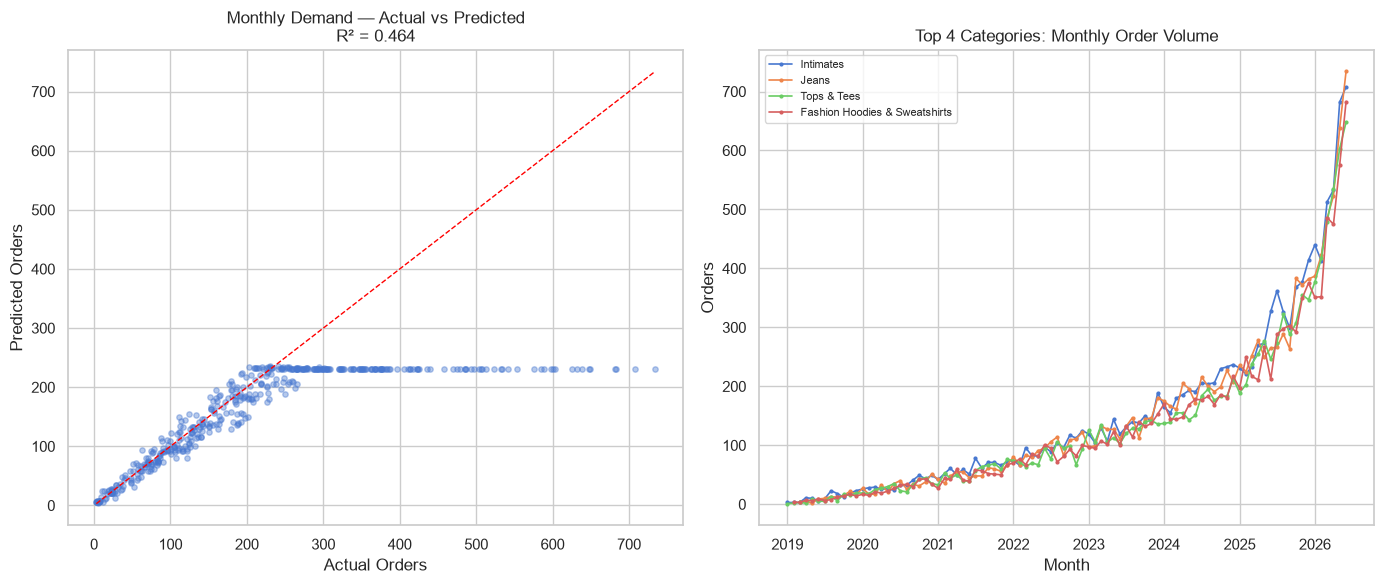

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# left plot: actual vs predicted
ax1.scatter(
    y_test_d,
    pred_demand,
    alpha=0.4,
    s=15
)

minimum = min(y_test_d.min(), pred_demand.min())
maximum = max(y_test_d.max(), pred_demand.max())

ax1.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=1,
    color="red"
)

ax1.set_title(f"Monthly Demand — Actual vs Predicted\nR² = {demand_r2:.3f}")
ax1.set_xlabel("Actual Orders")
ax1.set_ylabel("Predicted Orders")

# right plot: top 4 categories monthly volume
top_categories = (
    monthly_cat
    .groupby("product_category")["orders"]
    .sum()
    .nlargest(4)
    .index
)

top_category_demand = monthly_cat[
    monthly_cat["product_category"].isin(top_categories)
]

for category in top_categories:
    category_data = top_category_demand[
        top_category_demand["product_category"] == category
    ].sort_values("month")

    ax2.plot(
        category_data["month"],
        category_data["orders"],
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=category
    )

ax2.set_title("Top 4 Categories: Monthly Order Volume")
ax2.set_xlabel("Month")
ax2.set_ylabel("Orders")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2.2 Predict Monthly Category Demand with Linear Regression

Predict how many orders each product category receives per month using last month's demand and a time trend. A naive lag-1 baseline is included for comparison.

In [22]:
# Monthly category demand — linear regression with lag + time trend

# Monthly order counts per category
results_demand = results.copy()
results_demand['month'] = pd.to_datetime(
    results_demand['order_created_at'], format='mixed', utc=True
).dt.to_period('M').dt.to_timestamp()

monthly_cat = (
    results_demand.groupby(['product_category', 'month'])
    .size()
    .reset_index(name='orders')
    .sort_values(['product_category', 'month'])
)

# Lag features and time index per category
month_start = monthly_cat['month'].min()
lag_frames = []
for cat, g in monthly_cat.groupby('product_category'):
    g = g.sort_values('month').copy()
    g['lag1'] = g['orders'].shift(1)
    g['t'] = ((g['month'] - month_start).dt.days // 30).astype(int)
    lag_frames.append(g)

monthly_demand = pd.concat(lag_frames).dropna()
monthly_demand['lag1 * t'] = monthly_demand['lag1'] * monthly_demand['t']
feature_cols_demand = ['lag1', 't', 'lag1 * t']

# Time-based split — train on earlier months, test on later months
split_month = monthly_demand['month'].quantile(0.8)
train_demand = monthly_demand[monthly_demand['month'] <= split_month]
test_demand = monthly_demand[monthly_demand['month'] > split_month]

X_train_d = train_demand[feature_cols_demand]
X_test_d = test_demand[feature_cols_demand]
y_train_d, y_test_d = train_demand['orders'], test_demand['orders']

# Primary model: linear regression on lag1 + time trend
demand_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
demand_model.fit(X_train_d, y_train_d)
pred_demand = demand_model.predict(X_test_d)

# Baseline: naive forecast (predict last month's orders)
pred_naive = test_demand['lag1'].values

def demand_metrics_row(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'Train rows': len(train_demand),
        'Test rows': len(test_demand),
    }

demand_metrics = pd.DataFrame([
    demand_metrics_row('Linear (lag1 + time + lag1 * time)', y_test_d, pred_demand),
    demand_metrics_row('Naive (lag1)', y_test_d, pred_naive),
]).round(3)

print('Monthly Category Demand: Model Performance')
display(demand_metrics)

coef = demand_model.named_steps['model'].coef_
intercept = demand_model.named_steps['model'].intercept_
print(f'Coefficients (scaled features): lag1={coef[0]:.2f}, time={coef[1]:.2f}, intercept={intercept:.2f}')

# Results table: actual vs predicted
demand_results = test_demand[['product_category', 'month', 'orders']].copy()
demand_results['predicted_orders'] = pred_demand.round(1)
demand_results['naive_orders'] = pred_naive.round(1)
demand_results['residual'] = demand_results['orders'] - demand_results['predicted_orders']
print('\nSample predictions (test set):')
display(demand_results.head(15))

Monthly Category Demand: Model Performance


,Model,R²,RMSE,MAE,Train rows,Test rows
0,Linear (lag1 + time + lag1 * time),0.960,29.430,20.388,1801,442
1,Naive (lag1),0.948,33.676,22.952,1801,442


Coefficients (scaled features): lag1=43.98, time=0.71, intercept=49.90

Sample predictions (test set):


,product_category,month,orders,predicted_orders,naive_orders,residual
73,Accessories,2025-02-01,184,202.5,197.0,-18.5
74,Accessories,2025-03-01,187,189.6,184.0,-2.6
75,Accessories,2025-04-01,195,192.9,187.0,2.1
76,Accessories,2025-05-01,204,201.3,195.0,2.7
77,Accessories,2025-06-01,211,210.6,204.0,0.4
78,Accessories,2025-07-01,254,218.0,211.0,36.0
79,Accessories,2025-08-01,209,261.9,254.0,-52.9
80,Accessories,2025-09-01,229,216.6,209.0,12.4
81,Accessories,2025-10-01,264,237.2,229.0,26.8
82,Accessories,2025-11-01,246,273.1,264.0,-27.1


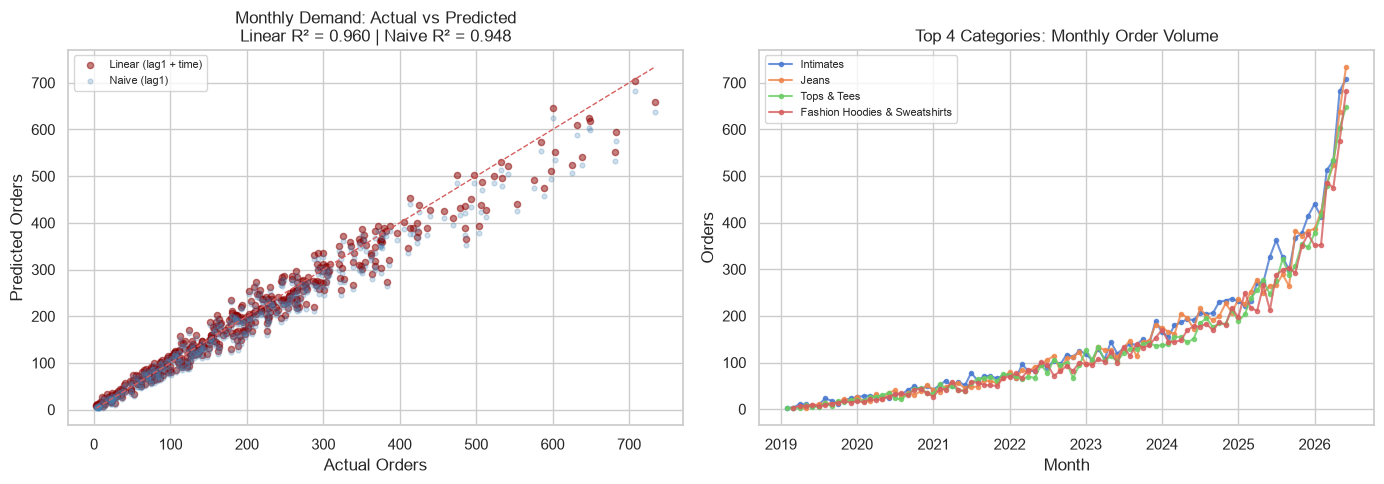

In [19]:
# Visualize monthly demand forecasts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted scatter
axes[0].scatter(y_test_d, pred_demand, alpha=0.5, s=20, color='darkred', label='Linear (lag1 + time)')
axes[0].scatter(y_test_d, pred_naive, alpha=0.25, s=12, color='steelblue', label='Naive (lag1)')
lims = [
    min(y_test_d.min(), pred_demand.min(), pred_naive.min()),
    max(y_test_d.max(), pred_demand.max(), pred_naive.max()),
]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Orders')
axes[0].set_ylabel('Predicted Orders')
axes[0].set_title(
    f'Monthly Demand: Actual vs Predicted\n'
    f'Linear R² = {r2_score(y_test_d, pred_demand):.3f} | Naive R² = {r2_score(y_test_d, pred_naive):.3f}'
)
axes[0].legend(fontsize=8)

# Top 4 categories over time
top4_cats = (
    monthly_demand.groupby('product_category')['orders']
    .sum().nlargest(4).index
)
for cat in top4_cats:
    sub = monthly_demand[monthly_demand['product_category'] == cat]
    axes[1].plot(sub['month'], sub['orders'], marker='o', markersize=3, label=cat, alpha=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Orders')
axes[1].set_title('Top 4 Categories: Monthly Order Volume')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2.3 Priority Matrix for Pricing Optimization



In [23]:
# Pricing optimization: compute unit economics and build priority rankings

pricing_data = sku_features[[
    'product_id', 'product_name', 'product_category', 'product_department',
    'sale_price', 'product_cost', 'units_sold',
]].copy()

pricing_data['profit_per_unit'] = pricing_data['sale_price'] - pricing_data['product_cost']
pricing_data['margin_pct'] = pricing_data['profit_per_unit'] / pricing_data['sale_price']
pricing_data['total_profit'] = pricing_data['profit_per_unit'] * pricing_data['units_sold']


# Within-category margin dispersion
pricing_data['category_median_margin'] = (
    pricing_data.groupby('product_category')['margin_pct'].transform('median')
)
pricing_data['margin_gap'] = pricing_data['category_median_margin'] - pricing_data['margin_pct']
pricing_data['below_category_margin'] = pricing_data['margin_gap'] > 0

within_cat_std = pricing_data.groupby('product_category')['margin_pct'].std().mean()
print(
    f'\nAverage within-category margin std: {within_cat_std:.3f} '
    f'(margin varies substantially within categories → SKU-level pricing matters)'
)

# Category profit rankings 
category_pricing = (
    pricing_data.groupby('product_category', as_index=False)
    .agg(
        avg_margin_pct=('margin_pct', 'mean'),
        avg_price=('sale_price', 'mean'),
        avg_cost=('product_cost', 'mean'),
        total_units=('units_sold', 'sum'),
        total_profit=('total_profit', 'sum'),
        n_skus=('product_id', 'count'),
        n_below_median_margin=('below_category_margin', 'sum'),
    )
    .assign(profit_per_unit=lambda df: df['total_profit'] / df['total_units'])
    .sort_values('total_profit', ascending=False)
)

print('\nCategory profit contribution (ranked by total profit):')
display(category_pricing.round(4).head(7))

# SKU repricing priorities: below peer margin + meaningful volume
repricing_candidates = (
    pricing_data[pricing_data['below_category_margin'] & (pricing_data['units_sold'] >= 5)]
    .assign(repricing_impact=lambda df: df['margin_gap'] * df['sale_price'] * df['units_sold'])
    .sort_values('total_profit', ascending=False)
    [['product_name', 'product_category', 'sale_price', 'product_cost',
      'margin_pct', 'category_median_margin', 'margin_gap',
      'units_sold', 'total_profit', 'repricing_impact']]
)

print(
    f'\nTop repricing opportunities (below category median margin, ≥5 units sold): '
    f'{len(repricing_candidates):,} SKUs'
)
display(repricing_candidates.head(7).round(4))

# Priority matrix: margin vs recent demand (links to 2.1 demand trends)
results_pricing = results.copy()
results_pricing['month'] = pd.to_datetime(
    results_pricing['order_created_at'], format='mixed', utc=True
).dt.to_period('M').dt.to_timestamp()

recent_cutoff = results_pricing['month'].max() - pd.DateOffset(months=6)
recent_orders = (
    results_pricing[results_pricing['month'] > recent_cutoff]
    .groupby('product_category').size()
    .reset_index(name='recent_orders')
)

priority_matrix = category_pricing.merge(recent_orders, on='product_category', how='left')
margin_med = priority_matrix['avg_margin_pct'].median()
demand_med = priority_matrix['recent_orders'].median()

def pricing_strategy(row):
    high_margin = row['avg_margin_pct'] >= margin_med
    high_demand = row['recent_orders'] >= demand_med
    if high_margin and high_demand:
        return 'Protect (high margin + high demand)'
    if high_margin and not high_demand:
        return 'Premium niche (high margin, low demand)'
    if not high_margin and high_demand:
        return 'Reprice urgently (low margin, high demand)'
    return 'Review costs (low margin, low demand)'

priority_matrix['strategy'] = priority_matrix.apply(pricing_strategy, axis=1)

print('\nCategory pricing strategy matrix (margin vs. recent 6-month demand):')
display(
    priority_matrix[
        ['product_category', 'avg_margin_pct', 'recent_orders',
         'total_profit', 'strategy']
    ].head(7).sort_values('total_profit', ascending=False).round(4)
)


Average within-category margin std: 0.035 (margin varies substantially within categories → SKU-level pricing matters)

Category profit contribution (ranked by total profit):


,product_category,avg_margin_pct,avg_price,avg_cost,total_units,total_profit,n_skus,n_below_median_margin,profit_per_unit
11,Outerwear & Coats,0.5548,146.1071,65.0210,9129,751230.8870,1418,708,82.2906
7,Jeans,0.4641,97.8044,52.3926,12764,582191.2834,1996,996,45.6120
22,Sweaters,0.5214,75.3770,36.1207,11291,445830.1338,1732,859,39.4854
21,Suits & Sport Coats,0.5993,126.5556,50.7996,5012,381226.0365,739,365,76.0627
23,Swim,0.4886,57.8175,28.8850,11449,321469.3216,1797,897,28.0784
5,Fashion Hoodies & Sweatshirts,0.4879,53.8894,27.7954,11709,303665.9775,1859,926,25.9344
17,Sleep & Lounge,0.5063,49.1892,24.1983,11108,282147.3121,1768,883,25.4004



Top repricing opportunities (below category median margin, ≥5 units sold): 10,821 SKUs


,product_name,product_category,sale_price,product_cost,margin_pct,category_median_margin,margin_gap,units_sold,total_profit,repricing_impact
17998,The North Face Apex Bionic Soft Shell Jacket - Men's,Active,903.0,391.902,0.566,0.579,0.013,14,7155.372,164.346
22744,Quiksilver Men's Rockefeller Walkshort,Shorts,903.0,472.269,0.477,0.499,0.022,16,6891.696,317.856
24132,Mens Nike AirJordan Varsity Hoodie Jacket Grey / Black 451582-066,Outerwear & Coats,903.0,409.059,0.547,0.555,0.008,12,5927.292,86.688
23673,Canada Goose Men's Citadel Parka,Outerwear & Coats,795.0,387.165,0.513,0.555,0.042,11,4486.185,367.290
8287,Canada Goose Women's Mystique,Outerwear & Coats,750.0,353.250,0.529,0.555,0.026,10,3967.500,195.000
23984,The North Face Denali Down Mens Jacket 2013,Outerwear & Coats,903.0,436.149,0.517,0.555,0.038,8,3734.808,274.512
24041,Woolrich Arctic Parka DF,Outerwear & Coats,990.0,478.170,0.517,0.555,0.038,7,3582.810,263.340



Category pricing strategy matrix (margin vs. recent 6-month demand):


,product_category,avg_margin_pct,recent_orders,total_profit,strategy
0,Outerwear & Coats,0.5548,2291,751230.8870,Protect (high margin + high demand)
1,Jeans,0.4641,3189,582191.2834,"Reprice urgently (low margin, high demand)"
2,Sweaters,0.5214,2850,445830.1338,Protect (high margin + high demand)
3,Suits & Sport Coats,0.5993,1274,381226.0365,"Premium niche (high margin, low demand)"
4,Swim,0.4886,2903,321469.3216,"Reprice urgently (low margin, high demand)"
5,Fashion Hoodies & Sweatshirts,0.4879,2922,303665.9775,"Reprice urgently (low margin, high demand)"
6,Sleep & Lounge,0.5063,2690,282147.3121,Protect (high margin + high demand)


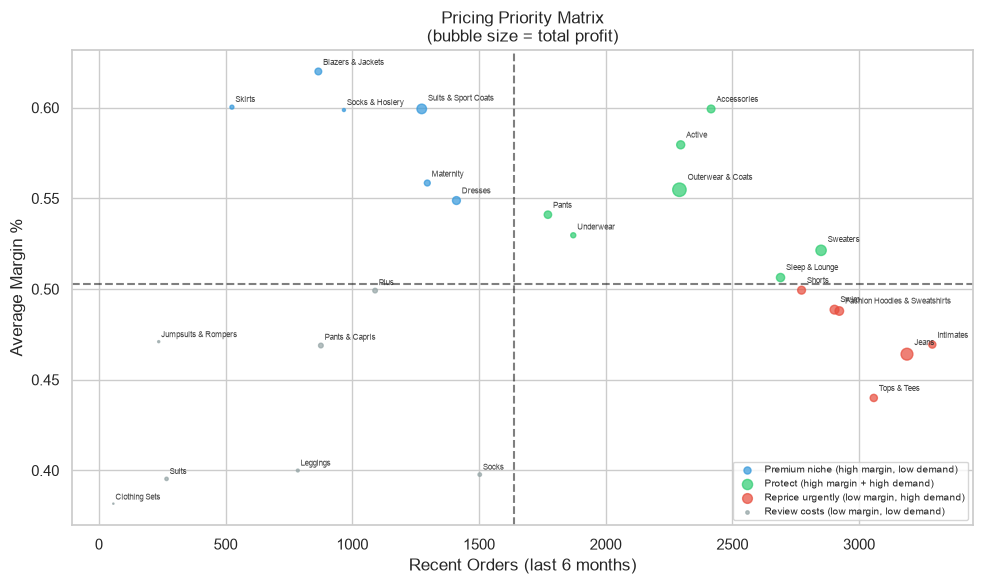

In [21]:
# Priority matrix plot (margin vs recent demand)
strategy_colors = {
    'Protect (high margin + high demand)': '#2ecc71',
    'Premium niche (high margin, low demand)': '#3498db',
    'Reprice urgently (low margin, high demand)': '#e74c3c',
    'Review costs (low margin, low demand)': '#95a5a6',
}

fig, ax = plt.subplots(figsize=(10, 6))

for strategy, sub in priority_matrix.groupby('strategy'):
    ax.scatter(
        sub['recent_orders'], sub['avg_margin_pct'],
        s=sub['total_profit'] / 8000, alpha=0.7,
        c=strategy_colors.get(strategy, 'gray'), label=strategy,
    )

for _, row in priority_matrix.iterrows():
    bubble_radius = np.sqrt(row['total_profit'] / 8000) / 2
    ax.annotate(
        row['product_category'],
        (row['recent_orders'], row['avg_margin_pct']),
        xytext=(bubble_radius + 1, bubble_radius + 1),
        textcoords='offset points',
        fontsize=6,
        ha='left',
        va='bottom',
        alpha=0.85,
    )

ax.axhline(margin_med, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.axvline(demand_med, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Recent Orders (last 6 months)')
ax.set_ylabel('Average Margin %')
ax.set_title('Pricing Priority Matrix\n(bubble size = total profit)')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()